# Compute and Compare FPTs

# Importations

In [1]:
import numpy as np

import sys
import time
from tqdm import tqdm
import copy
from scipy.io import savemat, loadmat

from scipy.optimize import curve_fit

#from multiprocessing import Pool

from numba import njit

In [2]:
# import simulations.langevin.ComputeObservables as co

In [3]:
from FirstPassageTime import *

In [4]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpltools import annotation
from matplotlib import rc
import seaborn as sns
from matplotlib import rc
import seaborn as sns
custom_params = {
    "xtick.direction": "in",
    "ytick.direction": "in",
    "lines.markeredgecolor": "k",
    "lines.markeredgewidth": 0.3,
    "figure.dpi": 200,
    "text.usetex": True,
    "font.family": "serif",
}

sns.set_theme(context = "notebook", style="ticks", rc=custom_params)

BlueUB = (0, 157/255, 224/255)
BrownUB = (68/255, 58/255, 49/255)
#rc('lines', linewidth=1.5, markeredgecolor='k', markeredgewidth=0.3)
#rc('xtick', direction='in', labelsize=5)
#rc('ytick', direction='in', labelsize=5)
#rc('font', family='serif', size=5)
#rc('text', usetex=True)
#rc('figure', dpi=500)
#rc('savefig', dpi=500)

# Auxiliary Functions

In [5]:
def compute_lB(a, drho, kT=4e-21, g=9.81):
    return kT / (4/3*np.pi*a**3*drho*g)

def compute_D0(eta, a, kT=4e-21):
    return kT/(6*np.pi*eta*a)

In [6]:
# Here z is the gap between the particle and the (bottom) wall

def diffusing_diffusivity_z(z, a):
    res = (6*(z**2) + 2*a*z) / (6*(z**2) + 9*a*z + 2*(a**2))
    return res

def diffusing_diffusivity_x(z, a):
    ksi = a / (a + z)
    res = (1 - (9/16)*(ksi) + (1/8)*(ksi**3) - (45/256)*(ksi**4) + (1/16)*(ksi**5))
    return res

In [7]:
def _P_eq(z, B, lD, lB):
    return np.exp(-B * np.exp(-z / lD) - z / lB)

def P_eq(z, B, lD, lB, normalize=True):
    if type(z) == float:
        if z < 0:
            res = 0
        return _P_eq(z, B, lD, lB)
    res = _P_eq(z, B, lD, lB)
    res[z < 0] = 0
    if normalize:
        res = res / np.trapezoid(res, z) # Ok because it is a change of variable
    return res

In [8]:
def Levy(t, L, D, x0=0):
    res = abs(L - x0) / np.sqrt(4*np.pi*D*t**3) * np.exp(-(L - x0)**2 / (4*D*t)) 
    return res

In [9]:
def logarithmic_hist(data, begin, stop, num=50, base=2, density=True):
    if begin == 0:
        beg = stop / num
        bins = np.logspace(
            np.log(beg) / np.log(base), 
            np.log(stop) / np.log(base), 
            num - 1, 
            base=base, 
        )
        widths = bins[1:] - bins[:-1]
        bins = np.cumsum(widths[::-1])
        bins = np.concatenate(([0], bins))
        widths = bins[1:] - bins[:-1]
    else:
        bins = np.logspace(
            np.log(begin) / np.log(base), 
            np.log(stop) / np.log(base), 
            num, 
            base=base, 
            dtype=np.float64, 
        )
        widths = bins[1:] - bins[:-1]
    hist, bins = np.histogram(data, bins=bins, density=density)
    # hist = hist / np.trapezoid(hist, bins)
    # normalize by bin width
    bins_center = (bins[1:] + bins[:-1]) / 2
    return bins_center, widths, hist

In [10]:
def find_rn(filepath):
    """
    Find the radius of the particle in the file path. 
    The trajectory (.mat) should be in the last folder considered.
    """
    try:
        filename = filepath[filepath.rfind('/')+1:]
        r = float(filename[filename.find('_rp_')+4:filename.find('_np_')].replace('p','.')) * 1e-6
        n_p = float(filename[filename.find('_np_')+4:filename.find('_vid')].replace('p','.'))
    except:
        print(filepath)
        r = input("Enter the radius in um = ")
        r = float(r) * 1e-6
        n_p = input("Enter the refractive index = ")
        n_p = float(n_p)
    return r, n_p

In [11]:
def str2var(string):
    return globals()[string]

# Load Data

## Experimental Data

In [12]:
# Load several .mat from experimental data
# copy paste the directory of the "traj.mat"
dir0_0 = r'/Users/guirecdetournemire/Desktop/PhD/paper/First Passage Time/github-FPT/data/traj3_lB604nm/traj_rp_1p4795_np_1p5803_vid_confined1.mat'


dt_0 = 0.01 #1/fps

dirs0 = [str2var('dir0_{}'.format(i)) for i in range(1)]

# For later, load experimental datas after analysis

# Then get MSDs, PDFs, ...

In [13]:
def mat2traj(dirs, N):
    xs, ys, zs = np.zeros((N, len(dirs))) * np.nan, np.zeros((N, len(dirs))) * np.nan , np.zeros((N, len(dirs))) * np.nan 
    for i, d in enumerate(dirs):
        data = loadmat(d, squeeze_me=True)
        x, y, z = data['x'], data['y'], data['z']
        #D = D_bulk * data['mean_D_para_from_MSD']
        xs[:,i] = x[:N]
        ys[:,i] = y[:N]
        zs[:,i] = z[:N]
    return xs, ys, zs

In [19]:
# Group-by procedure and loadmat
N_pts = len(loadmat(dirs0[0],squeeze_me=True)['x'])
xs_0, ys_0, zs_0 = mat2traj(dirs0, N_pts)

In [20]:
xs_0

array([[3.63850339e-05],
       [3.63823554e-05],
       [3.63381511e-05],
       ...,
       [0.00000000e+00],
       [0.00000000e+00],
       [0.00000000e+00]])

## Simulation Data

In [21]:
# Simulations are divided into 2 groups:
# 1/ A few simulations to mimic experiments, that are loaded and analyzed like experimental trajectories
# 2/ Optimal simulations (e.g. huge nb of trajectories) to ensure the best statistics possible.

In [22]:
# 1/

dir_simu_0 = ''
data = loadmat(dir_simu_0, squeeze_me=True)
xs_s0, zs_s0 = data['x'], data['z']
dt_s0 = data['dt']
del data

# To be done: get back PDFs, MSDs, etc., from the simulations

## Initialize Saving

In [23]:
tosave = {}


# Compute FPTs

In [24]:
Ls = [0.5e-6]

In [25]:
%%time 

#fpt_x_s0 = get_FPT_several_particles(xs_s0, dt_s0, Ls)

CPU times: user 5 µs, sys: 2 µs, total: 7 µs
Wall time: 13.8 µs


In [26]:
k = 0

#fpt_x = fpt_x_s0[k][~np.isnan(fpt_x_s0[k])]

#bins_FPT_x_s0, _, hist_FPT_x_s0 = logarithmic_hist(fpt_x, begin=np.min(fpt_x), stop=np.max(fpt_x), num=20, base=10, )

In [27]:
def traj2fpt(xs, dt, Ls, num=50, base=10):
    fpt_x = get_FPT_several_particles(xs, dt, Ls)
    if len(Ls) == 1:
        k = 0
        temp_fpt = fpt_x[k][~np.isnan(fpt_x[k])]
        bins_FPT_x, _, hist_FPT_x = logarithmic_hist(fpt_x, begin=np.min(temp_fpt), stop=np.max(temp_fpt), num=num, base=base, )
        return bins_FPT_x, hist_FPT_x
    else:
        bins_FPT_x, hist_FPT_x = [], []
        for k, l in enumerate(Ls):
            temp_fpt = fpt_x[k][~np.isnan(fpt_x[k])]
            bins, _, hist = logarithmic_hist(temp_fpt, begin=np.min(temp_fpt), stop=np.max(temp_fpt), num=num, base=base, ) #traj2fpt(xs, dt, [l], num=num, base=base)
            bins_FPT_x.append(bins)
            hist_FPT_x.append(hist)
        bins_FPT_x, hist_FPT_x = np.array(bins_FPT_x), np.array(hist_FPT_x)
        return bins_FPT_x, hist_FPT_x

### import the corresponding data from the analysis

In [267]:
data_path = ''

data_exp = loadmat(data_path, squeeze_me = True)
D0 = data_exp['D0']
mean_D_para = D0 * data_exp['mean_D_para_from_MSD']
mean_D_perp = D0 * data_exp['mean_D_perp_from_MSD']

### FPTs along $x$

In [28]:
bins_FPT_x_0, hist_FPT_x_0 = traj2fpt(xs_0, dt_0, Ls)

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  1.46it/s]

L = 0.5 um done.


In [30]:
bins_FPT_x_theory = np.logspace(np.log10(bins_FPT_x_0[0]), np.log10(bins_FPT_x_0[-1]), 100)

#hist_FPT_x_theory_bulk = Levy(t = bins_FPT_x_theory, L = Ls[0], D = D0, x0=0)
#hist_FPT_x_theory_confined = Levy(t = bins_FPT_x_theory, L = Ls[0], D = mean_D_para, x0=0)

#popt, _ = curve_fit(lambda t, D: Levy(t, L=Ls[0], D=D), bins_FPT_x_0, hist_FPT_x_0, p0=[mean_D_para])

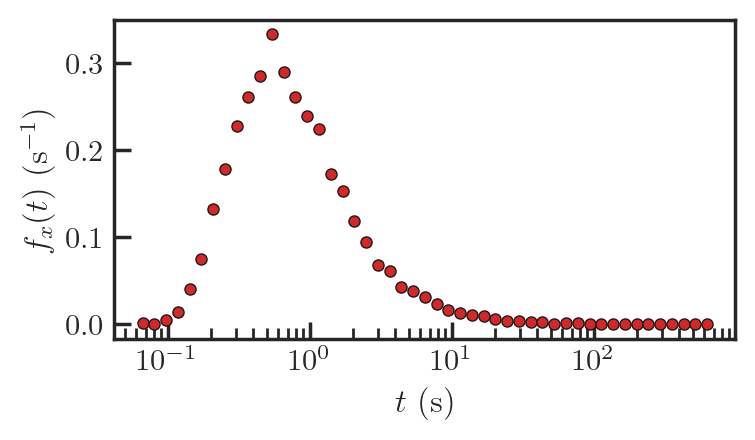

In [31]:
fig, ax = plt.subplots(1,1,figsize=(10/2.54,6/2.54))
#ax.loglog(bins_FPT_x_s0, hist_FPT_x_s0, 'o', label='Rigid')

ax.semilogx(bins_FPT_x_0, hist_FPT_x_0, 'o', color = 'tab:red', markersize = 4, markeredgewidth = 0.5, label='confined exp')    # experimental data
#ax.semilogx(bins_FPT_x_theory, hist_FPT_x_theory_bulk, '-', c='tab:red', label=r'bulk theory', zorder=3)   # bulk theory
#ax.semilogx(bins_FPT_x_theory, hist_FPT_x_theory_confined, '--', c='k', label=r'confined theory', zorder=3)   # confined theory
#ax.semilogx(bins_FPT_x_theory, Levy(bins_FPT_x_theory, L=Ls[0], D=popt[0]), '-', c = 'tab:blue', label = 'fit of $D$')


ax.set_xlabel(r'$t$ (s)')
ax.set_ylabel(r'$f_x(t)$ (s$^{-1}$)')
plt.tight_layout()
plt.show()

In [272]:
def delta_t_max(bins, hist_theory, hist_data):
    index_max_bulk = np.argmax(hist_theory)
    index_max_fit = np.argmax(hist_data)

    t_max_bulk = bins[index_max_bulk]
    t_max_fit = bins[index_max_fit]

    res = (t_max_fit - t_max_bulk) / t_max_bulk

    return res

In [273]:
delta_t = delta_t_max(bins_FPT_x_theory, hist_FPT_x_theory_bulk, Levy(bins_FPT_x_theory, L=500e-9, D=popt[0]))

In [274]:
delta_t

np.float64(0.4450871383798218)

In [275]:
tosave = {}

In [276]:
tosave['D0'] = D0
tosave['meanDx_MSD'] = mean_D_para
tosave['bins_FPT_x'] = bins_FPT_x_0
tosave['hist_FPT_x'] = hist_FPT_x_0
tosave['bins_FPT_x_theory'] = bins_FPT_x_theory
tosave['hist_FPT_x_theory_bulk'] = hist_FPT_x_theory_bulk
tosave['hist_FPT_x_theory_confined'] = Levy(bins_FPT_x_theory, L=500e-9, D=mean_D_para)
tosave['delta_t'] = delta_t

## FPT along $z$

In [32]:
Ls = [0.3e-6]

In [33]:
bins_FPT_z_0, hist_FPT_z_0 = traj2fpt(zs_0, dt_0, Ls)

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  5.07it/s]


L = 0.3 um done.


In [34]:
#bins_FPT_z_theory = np.logspace(np.log10(bins_FPT_z_0[0]), np.log10(bins_FPT_z_0[-1]), 100)

#hist_FPT_z_theory_bulk = Levy(t = bins_FPT_z_theory, L = Ls[0], D = D0, x0=0)
#hist_FPT_z_theory_confined = Levy(t = bins_FPT_z_theory, L = Ls[0], D = mean_D_perp, x0=0)

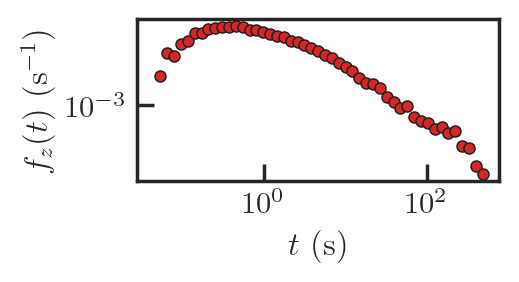

In [35]:
fig, ax = plt.subplots(1,1,figsize=(7/2.54,4/2.54))

ax.loglog(bins_FPT_z_0, hist_FPT_z_0, 'o', color = 'tab:red', markersize = 4, markeredgewidth = 0.5, label='confined exp')    # experimental data
#ax.plot(bins_FPT_z_theory, hist_FPT_z_theory_bulk, '-', c='tab:red', label=r'bulk theory', zorder=3)   # bulk theory
#ax.plot(bins_FPT_z_theory, hist_FPT_z_theory_confined, '--', c='k', label=r'confined theory', zorder=3)   # bulk theory

ax.set_xlabel(r'$t$ (s)')
ax.set_ylabel(r'$f_z(t)$ (s$^{-1}$)')
plt.tight_layout()
plt.show()

In [281]:
tosave['bins_FPT_z'] = bins_FPT_z_0
tosave['hist_FPT_z'] = hist_FPT_z_0
tosave['bins_FPT_z_theory'] = bins_FPT_z_theory
tosave['hist_FPT_z_theory_bulk'] = hist_FPT_z_theory_bulk
tosave['hist_FPT_z_theory_confined'] = hist_FPT_z_theory_confined

In [282]:
to_save_path = r'/Users/guirecdetournemire/Desktop/PhD/data/2025/20250916_PS3um_eg22/confined1/'
to_save_name = r'data_exp_lB1146m_Lx0p5um_Lz0p3um.mat'
data_exp_with_fpt = {**data_exp, **tosave}

savemat(to_save_path+to_save_name, data_exp_with_fpt)

this part is dedicated to find the dependance of the shift of the confined FPTD with the confinement